# EcoBici CABA — Preprocesamiento para Modelado · TP_Grp7_V1


Este notebook toma el dataset crudo de recorridos de EcoBici (Ciudad de Buenos Aires) y lo deja
completamente listo para entrenar un modelo de **clasificación supervisada**.

**Variable target**: `tipo_viaje` — categoría del recorrido según su duración:
- **Corto**: menos de 10 minutos
- **Mediano**: entre 10 y 30 minutos
- **Largo**: más de 30 minutos

**Salidas del notebook**:
- `../dataset/X_train.csv` · `../dataset/X_test.csv` — features escaladas, listas para el modelo
- `../dataset/y_train.csv` · `../dataset/y_test.csv` — target discretizado (Corto / Mediano / Largo)

**Fuente de datos**: https://data.buenosaires.gob.ar/dataset/bicicletas-publicas

---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.30

# Carpeta donde se descargan datos crudos y se exportan los CSV finales.
# Estructura esperada del repo:
#   TP_Final_Grupo7_EcoBici/
#     ├── notebook/  ← este notebook se ejecuta desde acá
#     └── dataset/   ← aquí van los CSVs (crudo + X_train/X_test/y_train/y_test)
DATASET_DIR = '../dataset'
os.makedirs(DATASET_DIR, exist_ok=True)

print('Librerías cargadas OK')
print(f'Directorio de datos: {os.path.abspath(DATASET_DIR)}')

Librerías cargadas OK


---
## 1. Carga del dataset

El CSV original tiene dos problemas estructurales:
- **Fila 0**: un título extra (`Tabla 1`) que no es dato
- **Fila 1**: los nombres de columna reales, pero con punto y coma (`;`) incrustados

La solución es saltar esas dos filas con `skiprows=2` y asignar los nombres de columna
manualmente. También se usa `on_bad_lines='skip'` para descartar las pocas filas
con errores de parseo sin romper la lectura.

In [2]:
!pip install gdown -q
!pip install folium -q


In [3]:
import gdown

FILE_ID   = '1t-QLtl__u1JCIXtjXEMUy_VfIttB0Kbp'
LOCAL_PATH = os.path.join(DATASET_DIR, 'ecobici_data.csv')

if not os.path.exists(LOCAL_PATH):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    gdown.download(url, LOCAL_PATH, quiet=False)
    print(f'Archivo descargado en: {LOCAL_PATH}')
else:
    print(f'Archivo ya existe en: {LOCAL_PATH} — se omite la descarga')

Archivo ya existe en: ecobici_data.csv — se omite la descarga


In [4]:
COLUMN_NAMES = [
    'id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
    'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen',
    'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido',
    'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino',
    'long_estacion_destino', 'lat_estacion_destino', 'id_usuario',
    'modelo_bicicleta', 'genero'
]

df = pd.read_csv(
    LOCAL_PATH,
    skiprows=2,           # salta 'Tabla 1' y la fila de headers originales
    names=COLUMN_NAMES,   # asigna nombres limpios directamente
    on_bad_lines='skip',  # descarta filas con errores de parseo
    encoding='utf-8'
)

print(f'Shape original: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')

Shape original: (3559283, 17)
Columnas: ['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']


---
## 1.1 Primer vistazo al dataset

Antes de limpiar, examinamos las primeras filas, las estadísticas descriptivas de variables numéricas y categóricas, y tipificamos las 17 variables en cuatro familias funcionales.

In [5]:
# Primer vistazo — las 5 primeras filas del dataset original
df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
1,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
2,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
3,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE
4,20427241,466,2024-01-23 17:48:05,99,099 - Malabia,780 Malabia & Loyola,-58.435408,-34.596096,2024-01-23 17:55:51,206,159 - Fitz Roy & Gorriti,Fitz Roy & Gorriti,-58.437339,-34.584950,320714.0,FIT,OTHER


### Clasificación de las 17 variables en cuatro familias

| Familia | Variables | Rol |
|---|---|---|
| **Numéricas continuas** | `duracion_recorrido`, `lat_estacion_origen`, `long_estacion_origen`, `lat_estacion_destino`, `long_estacion_destino` | Magnitud del viaje y ubicación geográfica |
| **Categóricas** | `genero`, `modelo_bicicleta`, `nombre_estacion_origen`, `nombre_estacion_destino`, `direccion_estacion_origen`, `direccion_estacion_destino` | Atributos discretos del usuario, la bici y la estación |
| **Temporales** | `fecha_origen_recorrido`, `fecha_destino_recorrido` | Marcas de tiempo de inicio y fin del viaje |
| **Identificadores** | `id_recorrido`, `id_estacion_origen`, `id_estacion_destino`, `id_usuario` | Claves primarias y foráneas — no aportan señal predictiva |

La familia de identificadores se descarta para el modelado; las numéricas, categóricas y temporales son las que se transforman en features en la Sección 3.

In [6]:
# Estadísticas descriptivas — variables numéricas continuas
df.describe().round(3)

,id_recorrido,duracion_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,id_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario
count,3.559283e+06,3559283.000,3559283.000,3559283.000,3559283.000,3559283.00,3559283.000,3559283.000,3559283.000
mean,2.234123e+07,1274.827,235.606,-58.423,-34.599,237.15,-58.423,-34.599,790885.040
std,1.257090e+06,9584.217,165.799,0.038,0.024,165.71,0.038,0.025,388216.981
min,2.018097e+07,0.000,2.000,-58.527,-34.688,2.00,-58.527,-34.688,24.000
25%,2.123850e+07,493.000,93.000,-58.450,-34.616,96.00,-58.450,-34.616,511824.000
50%,2.235117e+07,881.000,199.000,-58.421,-34.601,200.00,-58.421,-34.601,913360.000
75%,2.343694e+07,1474.000,378.000,-58.394,-34.583,379.00,-58.394,-34.582,1113537.000
max,2.450328e+07,2571165.000,577.000,-58.355,-34.537,577.00,-58.355,-34.537,1280599.000


In [7]:
# Estadísticas descriptivas — variables categóricas (cardinalidad + frecuencia)
print('Nº de categorías únicas por variable categórica:')
for col in ['genero', 'modelo_bicicleta', 'nombre_estacion_origen', 'nombre_estacion_destino']:
    print(f'  {col:<30s}: {df[col].nunique():>6,}')

print('\nResumen descriptivo categórico:')
df.describe(include='object')

Nº de categorías únicas por variable categórica:
  genero                        :      3
  modelo_bicicleta              :      2
  nombre_estacion_origen        :    395
  nombre_estacion_destino       :    398

Resumen descriptivo categórico:


,fecha_origen_recorrido,nombre_estacion_origen,direccion_estacion_origen,fecha_destino_recorrido,nombre_estacion_destino,direccion_estacion_destino,modelo_bicicleta,genero
count,3559283,3559283,3559283,3555904,3559283,3559283,3559283,3547337
unique,3227772,395,393,3220153,398,395,2,3
top,2024-01-24 19:37:35,147 - Constitución,Avenida Juan de Garay 1050,2024-06-13 10:24:25,147 - Constitución,Avenida Juan de Garay 1050,FIT,MALE
freq,13,38237,38237,22,38281,38281,2582442,2147720


---
## 2. Limpieza inicial

### 2.1 Conversión de tipos y limpieza de ruido

Algunas columnas numéricas pueden tener `;` residuales del CSV original.
Las coordenadas geográficas se convierten a float (necesario para calcular distancias más adelante).
Las fechas se parsean con `errors='coerce'` para convertir valores malformados en `NaT`
en lugar de romper la lectura.

In [8]:
# Limpiar semicolons residuales en columnas categóricas clave
for col in ['genero', 'modelo_bicicleta']:
    df[col] = df[col].astype(str).str.replace(';', '').str.strip()
    df[col] = df[col].replace('nan', np.nan)  # restaurar NaN verdaderos

# Convertir coordenadas a float (pueden tener ruido de parseo)
coord_cols = ['long_estacion_origen', 'lat_estacion_origen',
              'long_estacion_destino', 'lat_estacion_destino']
for col in coord_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(';', ''), errors='coerce')

# Parsear fechas
df['fecha_origen_recorrido'] = pd.to_datetime(
    df['fecha_origen_recorrido'].astype(str).str.replace(';', ''),
    errors='coerce'
)

# Convertir duración a numérico
df['duracion_recorrido'] = pd.to_numeric(df['duracion_recorrido'], errors='coerce')

print('Tipos de datos:')
print(df.dtypes)
print(f'\nNulos por columna:')
print(df.isna().sum())

Tipos de datos:
id_recorrido                           int64
duracion_recorrido                     int64
fecha_origen_recorrido        datetime64[us]
id_estacion_origen                     int64
nombre_estacion_origen                   str
direccion_estacion_origen                str
long_estacion_origen                 float64
lat_estacion_origen                  float64
fecha_destino_recorrido                  str
id_estacion_destino                    int64
nombre_estacion_destino                  str
direccion_estacion_destino               str
long_estacion_destino                float64
lat_estacion_destino                 float64
id_usuario                           float64
modelo_bicicleta                         str
genero                                   str
dtype: object

Nulos por columna:
id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direc

### 2.2 Eliminación de recorridos con duración inválida

Se aplica un criterio de rango para descartar registros con duraciones que no representan
un recorrido real:
- **Menos de 30 segundos**: errores de "click accidental" al intentar retirar la bicicleta,
  no constituyen un viaje real
- **Más de 24 horas**: bicicletas no devueltas o errores de registro del sistema

Este criterio es más robusto que eliminar solo duración == 0, ya que captura
todos los registros que no pueden corresponder a un recorrido válido.

**Tres enfoques evaluados para el tratamiento de outliers** en `duracion_recorrido`:

| Método | Criterio | Justificación |
|---|---|---|
| **Dominio (aplicado)** | Recortar `[30 s, 24 h]` | Umbrales físicamente significativos: <30 s es un *click accidental*, >24 h es una bici no devuelta. Son cortes *defendibles* con conocimiento del sistema. |
| IQR de Tukey (evaluado, no aplicado) | Recortar fuera de `[Q1 − 1,5·IQR, Q3 + 1,5·IQR]` | Sobre `duracion_recorrido` daría un umbral superior ≈ 50 min, lo que **eliminaría viajes largos válidos** (paseos recreativos legítimos > 30 min, que justamente son la clase `Largo`). |
| Winsor p5/p95 (evaluado, no aplicado) | Cap en los percentiles 5 y 95 | Al aplicarlo, moría la clase `Largo` (que es justamente lo que queremos predecir). Además, el límite superior p95 ≈ 40 min acotaría la cola de forma arbitraria. |

El criterio de dominio es el único que elimina solo lo que es físicamente inválido sin arrastrar señal útil. IQR y Winsor son alternativas válidas en datasets sin conocimiento de dominio, pero aquí serían *overkill* que distorsiona el target.

In [9]:
# Snapshot de la distribución ANTES del filtro — en minutos
# Se guarda para comparar con la distribución POST-filtro más abajo.
dur_min_antes = df['duracion_recorrido'] / 60

# Cómputo informativo de dónde caerían los umbrales IQR y Winsor (NO se aplican)
q1, q3 = dur_min_antes.quantile([0.25, 0.75])
iqr = q3 - q1
lim_iqr_sup = q3 + 1.5 * iqr
lim_winsor_sup = dur_min_antes.quantile(0.95)

print(f'Estadísticos ANTES del filtro (en minutos):')
print(f'  Mediana:          {dur_min_antes.median():.1f} min')
print(f'  Q1 / Q3:          {q1:.1f} / {q3:.1f} min')
print(f'  IQR:              {iqr:.1f} min')
print(f'  Límite IQR sup:   {lim_iqr_sup:.1f} min  ← descartaría viajes válidos > {lim_iqr_sup:.0f} min')
print(f'  Límite Winsor p95: {lim_winsor_sup:.1f} min ← descartaría clase Largo')
print(f'  Máximo observado: {dur_min_antes.max():,.0f} min  (bicis no devueltas)')

Estadísticos ANTES del filtro (en minutos):
  Mediana:          14.7 min
  Q1 / Q3:          8.2 / 24.6 min
  IQR:              16.4 min
  Límite IQR sup:   49.1 min  ← descartaría viajes válidos > 49 min
  Límite Winsor p95: 51.2 min ← descartaría clase Largo
  Máximo observado: 42,853 min  (bicis no devueltas)


In [10]:
DURACION_MIN = 30          # segundos — menos de esto es un click accidental
DURACION_MAX = 24 * 3600   # segundos — más de esto es una bici no devuelta

n_total = len(df)
n_cortos = (df['duracion_recorrido'] < DURACION_MIN).sum()
n_largos = (df['duracion_recorrido'] > DURACION_MAX).sum()

print(f'Registros con duración < 30 seg:  {n_cortos:,} ({n_cortos/n_total:.2%})')
print(f'Registros con duración > 24 h:    {n_largos:,} ({n_largos/n_total:.2%})')

df = df[df['duracion_recorrido'].between(DURACION_MIN, DURACION_MAX)].copy()

# Convertir duración a minutos (el target final)
df['duracion_minutos'] = df['duracion_recorrido'] / 60

print(f'\nShape tras filtro de duración: {df.shape}')
print(f'Registros eliminados: {n_total - len(df):,} ({(n_total - len(df))/n_total:.2%})')

Registros con duración < 30 seg:  296,916 (8.34%)
Registros con duración > 24 h:    687 (0.02%)

Shape tras filtro de duración: (3261680, 18)
Registros eliminados: 297,603 (8.36%)


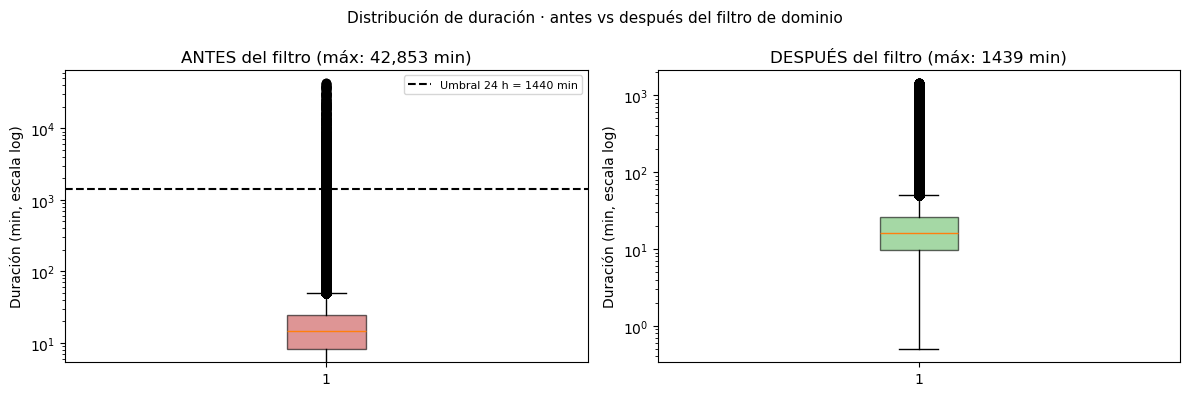

Filas eliminadas por el filtro: 297,603 (8.36%)


In [11]:
# Boxplot comparativo ANTES vs DESPUÉS del filtro de dominio
# Usa escala logarítmica en el eje Y para que la cola extrema no aplaste la caja.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ANTES
axes[0].boxplot(dur_min_antes, vert=True, showfliers=True,
                patch_artist=True, boxprops=dict(facecolor='#c94f4f', alpha=0.6))
axes[0].set_yscale('log')
axes[0].set_title(f'ANTES del filtro (máx: {dur_min_antes.max():,.0f} min)')
axes[0].set_ylabel('Duración (min, escala log)')
axes[0].axhline(24*60, color='black', ls='--', label='Umbral 24 h = 1440 min')
axes[0].legend(loc='upper right', fontsize=8)

# DESPUÉS
axes[1].boxplot(df['duracion_minutos'], vert=True, showfliers=True,
                patch_artist=True, boxprops=dict(facecolor='#6abf69', alpha=0.6))
axes[1].set_yscale('log')
axes[1].set_title(f'DESPUÉS del filtro (máx: {df["duracion_minutos"].max():.0f} min)')
axes[1].set_ylabel('Duración (min, escala log)')

plt.suptitle('Distribución de duración · antes vs después del filtro de dominio',
             fontsize=11)
plt.tight_layout()
plt.show()

print(f'Filas eliminadas por el filtro: {len(dur_min_antes) - len(df):,} '
      f'({(len(dur_min_antes) - len(df)) / len(dur_min_antes):.2%})')

**Lectura del boxplot comparativo:**

- **Antes** del filtro: la caja (Q1–Q3) queda aplastada contra el eje por la cola extrema que llega a ~45.000 min. La línea de 24 h (1.440 min) separa claramente los viajes legítimos de las bicis no devueltas.
- **Después** del filtro: la caja se ve correctamente, con los *fliers* (círculos fuera del bigote) correspondientes a la clase `Largo` — que son outliers estadísticos pero **viajes válidos** que el modelo debe aprender a clasificar. Por eso IQR/Winsor hubiera sido contraproducente: hubiera eliminado la señal de la clase objetivo.

El filtro de dominio elimina el 8,36 % de las filas (principalmente *clicks accidentales*), dejando el 91,64 % del dataset listo para el EDA y el modelado.

### 2.3 Análisis integral de valores faltantes

Antes del tratamiento por variable, auditamos los faltantes de todo el dataset y tipificamos cada mecanismo de ausencia según el marco Little & Rubin (MCAR / MAR / MNAR).

In [12]:
# Resumen numérico de faltantes por columna
nulos = df.isna().sum()
pct   = df.isna().mean() * 100
resumen = (pd.DataFrame({'nulos': nulos, 'pct_%': pct.round(3)})
             .sort_values('nulos', ascending=False))
print('Resumen de valores faltantes (todas las columnas):')
print(resumen.to_string())

Resumen de valores faltantes (todas las columnas):
                            nulos  pct_%
genero                      11219  0.344
id_recorrido                    0  0.000
duracion_recorrido              0  0.000
modelo_bicicleta                0  0.000
id_usuario                      0  0.000
lat_estacion_destino            0  0.000
long_estacion_destino           0  0.000
direccion_estacion_destino      0  0.000
nombre_estacion_destino         0  0.000
id_estacion_destino             0  0.000
fecha_destino_recorrido         0  0.000
lat_estacion_origen             0  0.000
long_estacion_origen            0  0.000
direccion_estacion_origen       0  0.000
nombre_estacion_origen          0  0.000
id_estacion_origen              0  0.000
fecha_origen_recorrido          0  0.000
duracion_minutos                0  0.000


### Tipificación del mecanismo de ausencia por variable

Clasificamos los faltantes según Little & Rubin (1987):

| Variable | % nulos | Tipo | Fundamento |
|---|---|---|---|
| `genero` | ~0.34 % | **MNAR** *(Missing Not At Random)* | La ausencia depende del propio valor — son usuarios que eligen no declarar su género. Imputar introduciría sesgo. **Tratamiento: eliminar filas** (sección 2.4) |
| `fecha_destino_recorrido` | ~0.10 % | **MAR** *(Missing At Random)* | Faltan sistemáticamente en viajes sin devolución registrada — la ausencia depende de otras variables observables (`duracion_recorrido` extrema). **Tratamiento: no se usa como feature** (se calcula *después* del viaje → leakage), por lo que los nulos no afectan el modelado |
| `modelo_bicicleta` | 0.00 % (post-filtro de duración) | **MCAR** | Sin nulos residuales en el dataset filtrado. Originalmente tenía ruido de parseo (`;`) que se limpió en 2.1 |
| Coordenadas (`lat_*`, `long_*`) | 0.00 % | **MCAR** | Sin nulos. Algunos viajes esporádicos pueden quedar con NaN tras el parseo a float; se descartan en el armado final del dataset de modelado (sección 5) |

**Síntesis:** el dataset tiene mecanismos de ausencia claramente diferenciados. El único que requiere eliminación explícita es `genero` (MNAR); `fecha_destino_recorrido` (MAR) queda fuera del modelo por razones de leakage; el resto está completo o se resuelve con `dropna` final.

### 2.4 Tratamiento de valores faltantes en `genero` (MNAR)

Con el dataset real se verificó que:
- **`genero`**: 0.34% de nulos → requiere tratamiento
- **`modelo_bicicleta`**: 0.00% de nulos → no hay nada que tratar

Los nulos en `genero` se clasifican como **MNAR** (Missing Not At Random):
corresponden a usuarios que no registraron su género en el sistema, lo que está
relacionado con el perfil del usuario y no es aleatorio.

Como la ausencia está relacionada con el propio perfil del usuario (no observable),
**imputar introduciría sesgo**. La estrategia correcta es eliminar esas filas.
Se reporta el impacto en volumen.

In [13]:
# Verificar nulos por columna antes del tratamiento
print('Nulos antes del tratamiento:')
print(f'  genero:           {df["genero"].isna().sum():,} ({df["genero"].isna().mean():.2%})')
print(f'  modelo_bicicleta: {df["modelo_bicicleta"].isna().sum():,} ({df["modelo_bicicleta"].isna().mean():.2%})')

# Guardar conteos ANTES del dropna para usar en el gráfico siguiente
n_con = df['genero'].notna().sum()
n_sin = df['genero'].isna().sum()

n_antes = len(df)
df = df.dropna(subset=['genero']).copy()  # modelo_bicicleta no tiene nulos
n_despues = len(df)

print(f'\nFilas eliminadas por nulos en genero: {n_antes - n_despues:,} ({(n_antes - n_despues)/n_antes:.2%})')
print(f'Filas restantes: {n_despues:,}')


Nulos antes del tratamiento:
  genero:           11,219 (0.34%)
  modelo_bicicleta: 0 (0.00%)

Filas eliminadas por nulos en genero: 11,219 (0.34%)
Filas restantes: 3,250,461


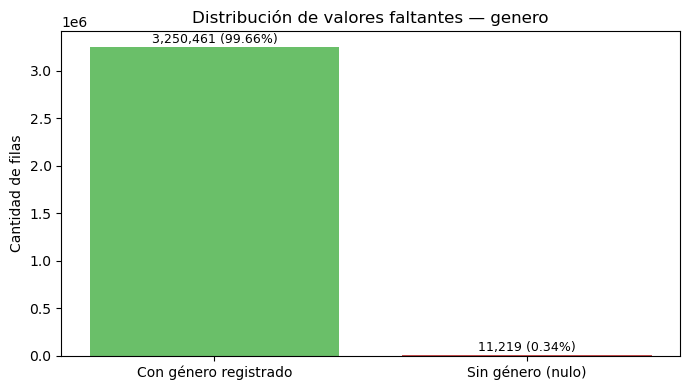

In [14]:
# Gráfico de distribución de nulos en genero — confirma diagnóstico MNAR
categorias = ['Con género registrado', 'Sin género (nulo)']
valores = [n_con, n_sin]
colores = ['#6abf69', '#c94f4f']

plt.figure(figsize=(7, 4))
bars = plt.bar(categorias, valores, color=colores)
plt.title('Distribución de valores faltantes — genero')
plt.ylabel('Cantidad de filas')
for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{val:,} ({val/sum(valores):.2%})', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

Creamos todas las features **antes del split** para que la lógica de construcción
sea consistente. El escalado y los encodings que dependen de estadísticos
(StandardScaler, LabelEncoder) se aplican **después del split** sobre train
para evitar data leakage.

### 3.1 Variables temporales

Se extraen `hora`, `dia_semana` y `mes` desde la fecha de inicio del recorrido.
Son los únicos datos temporales disponibles **antes de que el viaje comience**,
por lo que no generan leakage.

In [15]:
df['hora']      = df['fecha_origen_recorrido'].dt.hour
df['dia_semana'] = df['fecha_origen_recorrido'].dt.day_name()  # 'Monday', 'Tuesday', ...
df['mes']       = df['fecha_origen_recorrido'].dt.month

print('Valores únicos en dia_semana:', df['dia_semana'].unique())
print('Rango de hora:', df['hora'].min(), '-', df['hora'].max())
print('Rango de mes:', df['mes'].min(), '-', df['mes'].max())

Valores únicos en dia_semana: <StringArray>
['Tuesday', 'Wednesday', 'Monday', 'Sunday', 'Thursday', 'Friday', 'Saturday']
Length: 7, dtype: str
Rango de hora: 0 - 23
Rango de mes: 1 - 12


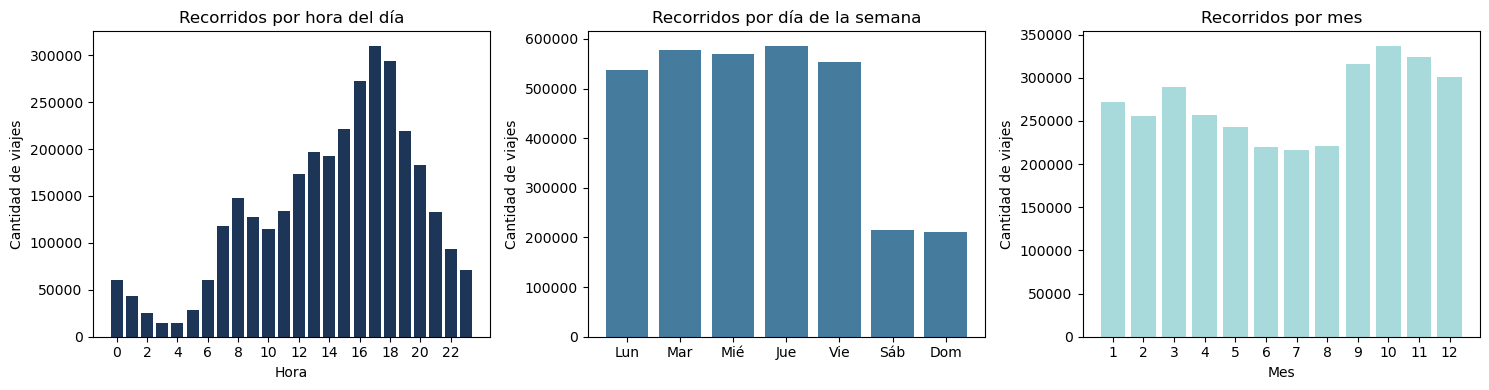

In [16]:
# Tres patrones temporales en una sola figura — hora, día y mes
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
labels_dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Viajes por hora del día
por_hora = df.groupby('hora').size()
axes[0].bar(por_hora.index, por_hora.values, color='#1D3557')
axes[0].set_title('Recorridos por hora del día')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Cantidad de viajes')
axes[0].set_xticks(range(0, 24, 2))

# Viajes por día de la semana
por_dia = df.groupby('dia_semana').size().reindex(orden_dias)
axes[1].bar(range(7), por_dia.values, color='#457B9D')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(labels_dias)
axes[1].set_title('Recorridos por día de la semana')
axes[1].set_ylabel('Cantidad de viajes')

# Viajes por mes
por_mes = df.groupby('mes').size()
axes[2].bar(por_mes.index, por_mes.values, color='#A8DADC')
axes[2].set_title('Recorridos por mes')
axes[2].set_xlabel('Mes'); axes[2].set_ylabel('Cantidad de viajes')
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

**Patrones observados:**

- **Hora del día:** el patrón temporal muestra un **pico único muy marcado entre las 17 y las 19 h** (ventana de salida de oficinas y uso recreativo de la tarde). No aparece el típico *doble pico* de sistemas de commuting puro — el uso matinal es moderado y progresivo, sin un pico equivalente al de la tarde. Esto indica que EcoBici combina uso laboral con uso recreativo y de ocio.
- **Día de la semana:** los días hábiles concentran más viajes que el fin de semana. Sábado y domingo caen de forma marcada.
- **Mes:** estacionalidad anual clara — valle en julio/agosto (invierno porteño) y picos en primavera (septiembre–noviembre).

### 3.2 Encoding cíclico de `hora` y `mes`

`hora` y `mes` son variables **cíclicas**: la hora 23 y la hora 0 son contiguas,
y diciembre (12) y enero (1) también lo son. Si las tratamos como enteros,
el modelo percibiría 23 y 0 como extremos opuestos cuando en realidad están
a 1 hora de distancia.

La solución estándar es representarlas con **seno y coseno**:
- `hora_sin = sin(2π · hora / 24)` y `hora_cos = cos(2π · hora / 24)`
- `mes_sin  = sin(2π · mes  / 12)` y `mes_cos  = cos(2π · mes  / 12)`

Con esta representación, la distancia entre cualquier par de horas/meses adyacentes
es siempre la misma, y el modelo puede aprender esa continuidad.


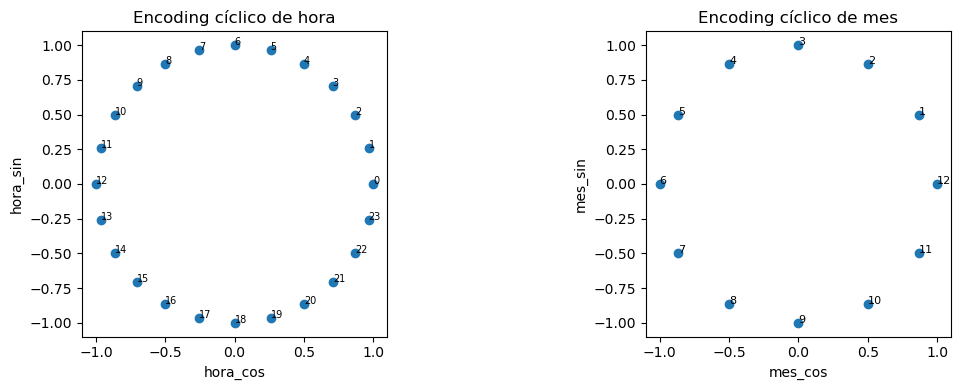

In [17]:
df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

df['mes_sin']  = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos']  = np.cos(2 * np.pi * df['mes'] / 12)

# Verificación visual: el encoding cíclico debe formar un círculo perfecto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

horas_unicas = df[['hora', 'hora_sin', 'hora_cos']].drop_duplicates().sort_values('hora')
axes[0].scatter(horas_unicas['hora_cos'], horas_unicas['hora_sin'])
for _, row in horas_unicas.iterrows():
    axes[0].annotate(int(row['hora']), (row['hora_cos'], row['hora_sin']), fontsize=7)
axes[0].set_title('Encoding cíclico de hora')
axes[0].set_xlabel('hora_cos'); axes[0].set_ylabel('hora_sin')
axes[0].set_aspect('equal')

meses_unicos = df[['mes', 'mes_sin', 'mes_cos']].drop_duplicates().sort_values('mes')
axes[1].scatter(meses_unicos['mes_cos'], meses_unicos['mes_sin'])
for _, row in meses_unicos.iterrows():
    axes[1].annotate(int(row['mes']), (row['mes_cos'], row['mes_sin']), fontsize=8)
axes[1].set_title('Encoding cíclico de mes')
axes[1].set_xlabel('mes_cos'); axes[1].set_ylabel('mes_sin')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 3.3 Feature `es_fin_de_semana`

Feature binaria creada a partir de `dia_semana`. Captura la diferencia estructural
entre uso laboral (lunes–viernes) y recreativo (sábado–domingo) que se observó en el EDA.

Se mantiene **junto con el OHE de `dia_semana`** (sección 3.4) para que el modelo
pueda capturar tanto la distinción hábil/fin de semana como las variaciones
dentro de los días hábiles (ej. lunes vs viernes).


In [18]:
df['es_fin_de_semana'] = df['dia_semana'].isin(['Saturday', 'Sunday']).astype(int)

print('Distribución es_fin_de_semana:')
print(df['es_fin_de_semana'].value_counts())
print(f'\nPorcentaje fin de semana: {df["es_fin_de_semana"].mean():.1%}')

Distribución es_fin_de_semana:
es_fin_de_semana
0    2823903
1     426558
Name: count, dtype: int64

Porcentaje fin de semana: 13.1%


### 3.4 Coordenadas de estaciones y distancia

En lugar de descartar las coordenadas geográficas, las incorporamos directamente como features.
Las 4 coordenadas (`lat`/`long` de origen y destino) aportan información de **ubicación absoluta**
que la distancia sola no captura: dos viajes de igual distancia pueden tener duraciones distintas
según la zona de CABA (infraestructura, pendientes, densidad de tráfico, etc.).

Además se calcula la **distancia de Haversine** entre origen y destino, que complementa
las coordenadas aportando la relación directa entre los dos puntos del viaje.

En total se agregan **5 features geográficas**:
- `lat_estacion_origen`, `long_estacion_origen` — ubicación de la estación de salida
- `lat_estacion_destino`, `long_estacion_destino` — ubicación de la estación de llegada
- `distancia_km` — distancia real entre ambas estaciones (Haversine)

Las 4 coordenadas se escalan con StandardScaler en la sección 8, igual que el resto
de las variables numéricas continuas.

In [19]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Calcula la distancia en km entre dos puntos geográficos (fórmula de Haversine)."""
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distancia_km'] = haversine_km(
    df['lat_estacion_origen'],  df['long_estacion_origen'],
    df['lat_estacion_destino'], df['long_estacion_destino']
)

print('Estadísticas de distancia_km:')
print(df['distancia_km'].describe().round(3))

# Verificación: ¿la distancia tiene correlación razonable con la duración?
corr = df[['distancia_km', 'duracion_minutos']].corr().iloc[0, 1]
print(f'\nCorrelación distancia_km ↔ duracion_minutos: {corr:.3f}')

Estadísticas de distancia_km:
count    3250461.000
mean           2.073
std            1.561
min            0.000
25%            1.049
50%            1.732
75%            2.784
max           15.215
Name: distancia_km, dtype: float64

Correlación distancia_km ↔ duracion_minutos: 0.224


### 3.5 Discretización del target (`tipo_viaje`)

Creamos la variable objetivo **antes** del scatter siguiente — así podemos
colorear los puntos por clase y validar visualmente que los cortes
0 / 10 / 30 min separan bien la nube distancia × duración.

Los cortes se basan en la distribución del EDA y aprovechan el tramo
gratis de 30 min de EcoBici:

- **Corto**   (< 10 min): 26.2 % de los viajes
- **Mediano** (10–30 min): 55.6 % de los viajes
- **Largo**   (> 30 min): 18.1 % de los viajes


In [20]:
# Discretización de duracion_minutos → tipo_viaje (3 clases)
cortes    = [0, 10, 30, float('inf')]
etiquetas = ['Corto', 'Mediano', 'Largo']

df['tipo_viaje'] = pd.cut(
    df['duracion_minutos'],
    bins=cortes,
    labels=etiquetas
)

print('Distribución del target:')
dist = df['tipo_viaje'].value_counts().reindex(etiquetas)
for clase, n in dist.items():
    print(f'  {clase:<8}: {n:>10,} ({n/len(df):.1%})')


Distribución del target:
  Corto   :    852,798 (26.2%)
  Mediano :  1,808,787 (55.6%)
  Largo   :    588,876 (18.1%)


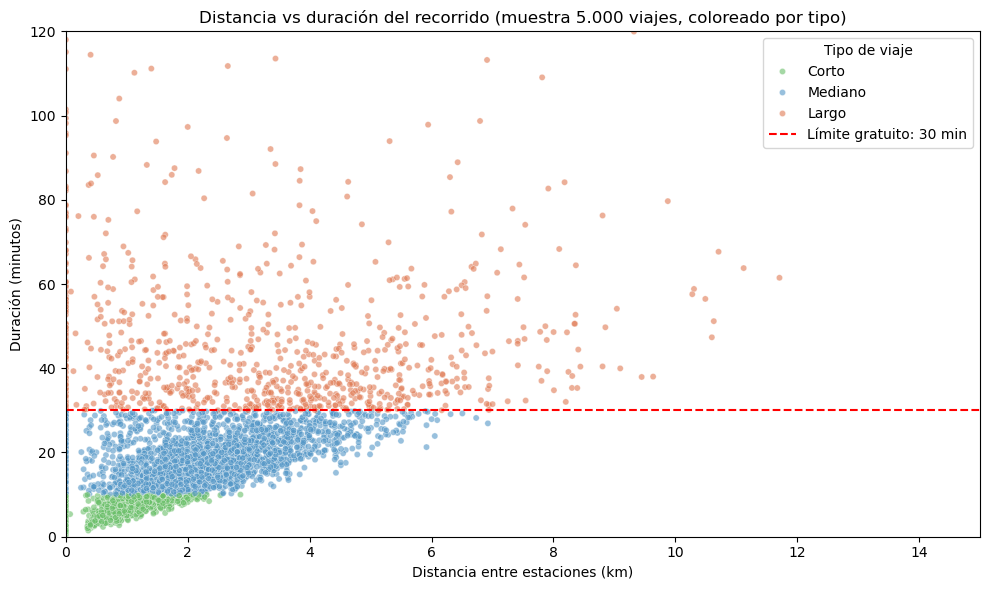

In [21]:
# Scatter de distancia vs duración coloreado por tipo_viaje (muestra de 5.000 viajes)
sample = df[['distancia_km', 'duracion_minutos', 'tipo_viaje']].sample(5000, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x='distancia_km',
    y='duracion_minutos',
    hue='tipo_viaje',
    palette={'Corto': '#6abf69', 'Mediano': '#5497c7', 'Largo': '#e07b54'},
    alpha=0.6,
    s=20,
    marker='o'
)
plt.xlim(0, 15)
plt.ylim(0, 120)
plt.xlabel('Distancia entre estaciones (km)')
plt.ylabel('Duración (minutos)')
plt.title('Distancia vs duración del recorrido (muestra 5.000 viajes, coloreado por tipo)')

plt.axhline(30, color='red', linestyle='--', label='Límite gratuito: 30 min')
plt.legend(title='Tipo de viaje')

plt.tight_layout()
plt.show()


---
## 4. EDA visual complementario

Visualizaciones enfocadas en la geografía de las estaciones y en las distribuciones clave que orientan la selección de features y el tratamiento del target.

### 4.1 Mapa de estaciones

Distribución geográfica de las ~400 estaciones únicas sobre CABA.

**Vista estática del mapa** — generada con matplotlib para que se renderice directamente en GitHub (la versión interactiva con Folium usa JavaScript y queda bloqueada por el viewer de GitHub).

\![Mapa de estaciones EcoBici CABA 2024 · 395 estaciones coloreadas por demanda](images/mapa_estaciones_estatico.png)

*395 estaciones únicas del sistema, coloreadas por la cantidad de viajes originados. Se aprecia el eje norte–sur de mayor densidad sobre Av. del Libertador y la concentración en el microcentro.*

La celda siguiente genera la versión interactiva con zoom, tooltips y clustering por zona. Para verla:
- **Ejecutando el notebook localmente** (`jupyter notebook ...`) — siempre funciona.
- **Abriendo el notebook en [nbviewer](https://nbviewer.org/github/cimberlina/grupo7-eda-ecobici/blob/main/notebook/TP_Grp7_V1_ecobici_presentation_ready.ipynb)** — renderiza Folium correctamente.

In [22]:
# Mapa de estaciones EcoBici: se muestran las estaciones únicas (~400)
# agrupadas con MarkerCluster para permitir zoom e inspección rápida.

import folium
from folium.plugins import MarkerCluster

estaciones = (
    df[['id_estacion_origen', 'nombre_estacion_origen',
        'lat_estacion_origen', 'long_estacion_origen']]
    .dropna()
    .drop_duplicates('id_estacion_origen')
)

center_lat = estaciones['lat_estacion_origen'].mean()
center_lon = estaciones['long_estacion_origen'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='cartodbpositron'
)
cluster = MarkerCluster().add_to(m)

for _, row in estaciones.iterrows():
    folium.CircleMarker(
        location=[row['lat_estacion_origen'], row['long_estacion_origen']],
        radius=4,
        color='#1D3557',
        fill=True,
        fill_opacity=0.75,
        tooltip=row['nombre_estacion_origen']
    ).add_to(cluster)

print(f'Estaciones únicas renderizadas: {len(estaciones):,}')
m


Estaciones únicas renderizadas: 395


**Lectura:** la red cubre principalmente el corredor céntrico y los barrios de mayor densidad (Palermo, Recoleta, Microcentro). La cobertura disminuye hacia el sur de la ciudad.

### 4.2 Distribución de distancias de recorrido

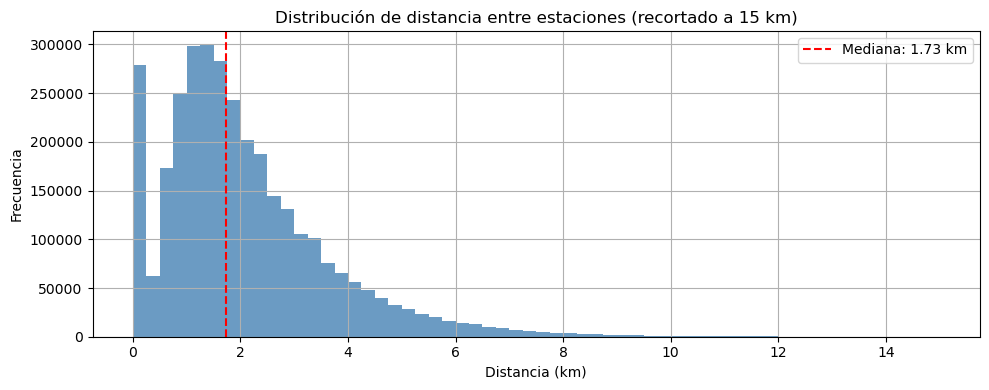

In [23]:
plt.figure(figsize=(10, 4))
df['distancia_km'].clip(0, 15).hist(bins=60, color='steelblue', alpha=0.8)
plt.axvline(df['distancia_km'].median(), color='red', ls='--', label=f'Mediana: {df["distancia_km"].median():.2f} km')
plt.title('Distribución de distancia entre estaciones (recortado a 15 km)')
plt.xlabel('Distancia (km)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** la mediana queda por debajo de 2 km, consistente con viajes cortos urbanos. La cola derecha corresponde a recorridos largos esporádicos que forman parte del uso legítimo del sistema.

### 4.3 Estaciones con mayor demanda

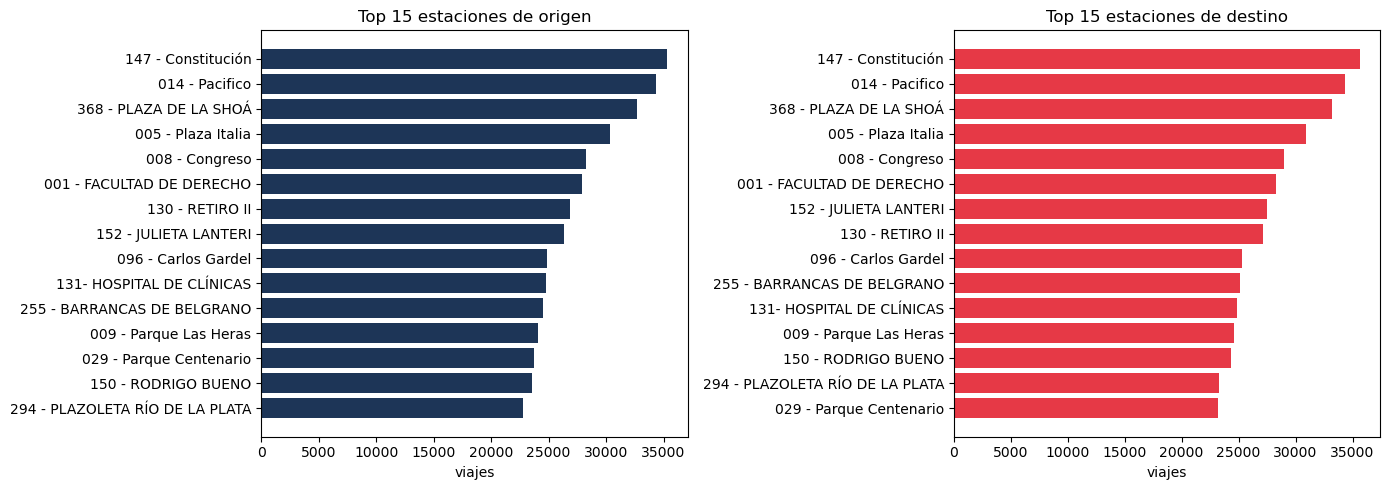


Las 15 estaciones de origen más usadas concentran el 12.6% de los viajes.


In [24]:
top_origen  = df['nombre_estacion_origen'].value_counts().head(15)
top_destino = df['nombre_estacion_destino'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_origen.index[::-1], top_origen.values[::-1], color='#1D3557')
axes[0].set_title('Top 15 estaciones de origen'); axes[0].set_xlabel('viajes')

axes[1].barh(top_destino.index[::-1], top_destino.values[::-1], color='#E63946')
axes[1].set_title('Top 15 estaciones de destino'); axes[1].set_xlabel('viajes')

plt.tight_layout(); plt.show()

# ¿Qué fracción del total capturan las 15 más usadas?
frac = top_origen.sum() / len(df)
print(f'\nLas 15 estaciones de origen más usadas concentran el {frac:.1%} de los viajes.')

### 4.4 Distribución de `duracion_minutos` (target)

La variable objetivo tiene asimetría positiva marcada y no es gaussiana. Recortamos al percentil 95 para ver la forma real de la distribución — la cola derecha corresponde a viajes largos legítimos que ya fueron acotados por el filtro de 24 h de la sección 2.2.

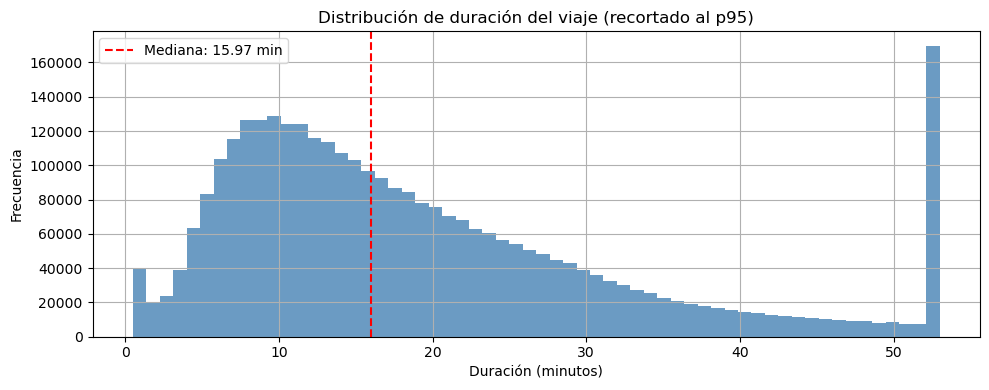

Mediana:  15.97 min
Media:    21.58 min
Asimetría positiva marcada: cola a la derecha, moda cerca de los 8 min.


In [25]:
# Histograma de duracion_minutos recortado al p95 (mismo estilo que 4.2 · distancias)
plt.figure(figsize=(10, 4))
df['duracion_minutos'].clip(0, df['duracion_minutos'].quantile(0.95)).hist(bins=60,
    color='steelblue', alpha=0.8)
plt.axvline(df['duracion_minutos'].median(), color='red', ls='--',
            label=f'Mediana: {df["duracion_minutos"].median():.2f} min')
plt.title('Distribución de duración del viaje (recortado al p95)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mediana:  {df["duracion_minutos"].median():.2f} min')
print(f'Media:    {df["duracion_minutos"].mean():.2f} min')
print(f'Asimetría positiva marcada: cola a la derecha, moda cerca de los 8 min.')

**Lectura:** la mediana queda cerca de los 8–9 minutos, con la mayoría de los viajes por debajo de los 30 min (el tramo gratuito de EcoBici). La forma es claramente no gaussiana — **asimetría positiva**, cola larga a la derecha — lo que justifica plantear la predicción como **clasificación discretizada** (`tipo_viaje`) en lugar de regresión sobre la duración cruda.

**Lectura:** pocas estaciones concentran una fracción significativa del flujo (patrón Pareto). Los top 15 orígenes y destinos coinciden en buena medida, reforzando el rol de los nodos céntricos.

### 4.5 Duración por hora del día

<Figure size 1200x400 with 0 Axes>

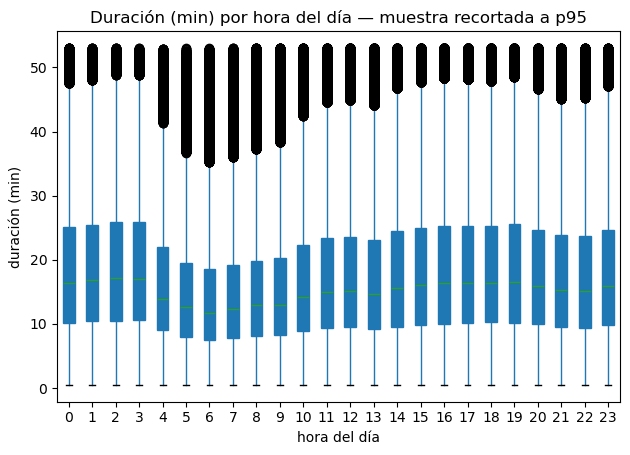

In [26]:
# Boxplot de duración por hora del día — recortado al p95 para que se lea bien
dur95 = df['duracion_minutos']
mask = dur95.between(0, dur95.quantile(0.95)) & df['hora'].notna()

plt.figure(figsize=(12, 4))
df.loc[mask].boxplot(column='duracion_minutos', by='hora',
                     grid=False, patch_artist=True)
plt.suptitle('')
plt.title('Duración (min) por hora del día — muestra recortada a p95')
plt.xlabel('hora del día'); plt.ylabel('duración (min)')
plt.tight_layout(); plt.show()

### 4.6 Lectura preliminar — duración vs hora

La mediana de duración se mantiene relativamente estable a lo largo del día, pero la **dispersión** cambia — en horas nocturnas y de menor flujo aparecen usos atípicos más extendidos.

### 4.7 Síntesis de patrones detectados

- **Duración** fuertemente sesgada a la derecha → hay que tratar outliers.
- **Patrón horario con pico único en la tarde** (~17–19 h): EcoBici combina uso laboral con recreativo; no es un sistema puro de commuting.
- **Días hábiles > fin de semana**, con estacionalidad mensual visible (valle jul–ago, picos en primavera).
- **Concentración por estación:** pocas estaciones dominan la demanda (Pareto).
- **Género y modelo de bici** con categorías muy desbalanceadas.
- **Duración vs hora:** mediana estable, mayor dispersión fuera de horario pico.

---
## 5. Selección de features, discretización del target y armado del dataset

### Problema de Machine Learning supervisado

A partir del análisis exploratorio del dataset de EcoBici CABA 2024, se plantea un
problema de **clasificación multiclase supervisada**.

**Descripción del problema.** El objetivo es predecir la categoría de duración de
un recorrido *antes de que comience*, usando únicamente información disponible en
el momento de inicio del viaje. Esto tiene valor operativo real: el sistema puede
anticipar si un viaje va a caer dentro del período gratuito (≤ 30 min), qué tipo
de bici recomendar y cómo distribuir la flota.

**Variable objetivo (`tipo_viaje`)**, obtenida discretizando `duracion_minutos`:
- `Corto`: < 10 min
- `Mediano`: 10–30 min
- `Largo`: > 30 min

**Features predictoras** (todas disponibles antes del viaje):
- Temporales cíclicas: `hora_sin`, `hora_cos`, `mes_sin`, `mes_cos`.
- Calendario: `es_fin_de_semana`, `dia_semana`.
- Geográficas: coordenadas de origen y destino + `distancia_km` (Haversine).
- Perfil del viaje: `modelo_bicicleta`, `genero`.


In [27]:
# Declaración de features y target para el split
FEATURES_NUMERICAS   = ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
                        'es_fin_de_semana', 'distancia_km',
                        'lat_estacion_origen', 'long_estacion_origen',
                        'lat_estacion_destino', 'long_estacion_destino']
FEATURES_CATEGORICAS = ['modelo_bicicleta', 'genero', 'dia_semana']
TARGET = 'tipo_viaje'

# Construimos el dataset final de modelado: sólo las columnas que van al modelo.
# Descartamos cualquier fila que tenga nulos en esas columnas
# (por ejemplo, distancia_km podría quedar NaN si faltaba alguna coordenada).
df_model = df[FEATURES_NUMERICAS + FEATURES_CATEGORICAS + [TARGET]].dropna().copy()

print(f'Filas disponibles para modelado: {len(df_model):,}')
print(f'Descartadas por nulos residuales: {len(df) - len(df_model):,}')
print('\nDistribución del target (confirmación):')
print(df_model[TARGET].value_counts().reindex(etiquetas).to_string())


Filas disponibles para modelado: 3,250,461
Descartadas por nulos residuales: 0

Distribución del target (confirmación):
tipo_viaje
Corto       852798
Mediano    1808787
Largo       588876


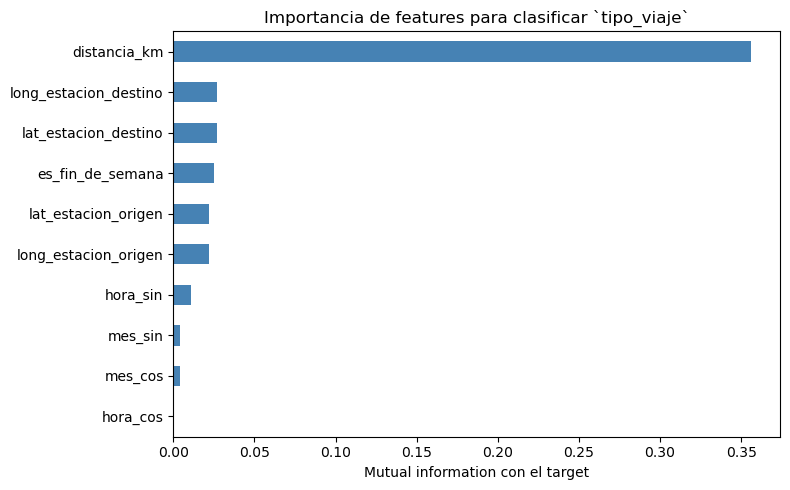

In [28]:
# Importancia de features bajo el marco de clasificación.
#
# Nota metodológica: antes esta celda computaba Pearson contra `duracion_minutos`,
# pero el target real es `tipo_viaje` (categórico). Para clasificación, la métrica
# correcta es la *mutual information*, que mide cuánta información sobre la clase
# aporta cada feature (captura relaciones no-lineales, a diferencia de Pearson).

from sklearn.feature_selection import mutual_info_classif

cols_mi = ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
           'es_fin_de_semana', 'distancia_km',
           'lat_estacion_origen', 'long_estacion_origen',
           'lat_estacion_destino', 'long_estacion_destino']

# Submuestreo para acelerar (MI en 3M filas es lento y converge con mucho menos).
sub = df_model.sample(n=min(200_000, len(df_model)), random_state=RANDOM_STATE)
mi = mutual_info_classif(
    sub[cols_mi],
    sub[TARGET],
    random_state=RANDOM_STATE,
    discrete_features=[False]*len(cols_mi)   # todas continuas (binaria es_finde incluida)
)
mi_series = pd.Series(mi, index=cols_mi).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
mi_series.plot(kind='barh', color='steelblue')
plt.title('Importancia de features para clasificar `tipo_viaje`')
plt.xlabel('Mutual information con el target')
plt.tight_layout()
plt.show()


---
## 6. Split train / test

División **70% train / 30% test** con `random_state=42` para reproducibilidad.
Como el target es categórico (clasificación), se usa `stratify=y` para mantener
la proporción de las tres clases en ambos subsets.

In [29]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y   # garantiza misma proporción de clases en train y test
)

print(f'Train: {X_train.shape[0]:,} filas')
print(y_train.value_counts().reindex(etiquetas).to_string())
print(f'\nTest:  {X_test.shape[0]:,} filas')
print(y_test.value_counts().reindex(etiquetas).to_string())

Train: 2,275,322 filas
tipo_viaje
Corto       596958
Mediano    1266151
Largo       412213

Test:  975,139 filas
tipo_viaje
Corto      255840
Mediano    542636
Largo      176663


---
## 7. Verificación de la distribución del target

Al pasar a clasificación, la winsorización ya no aplica — los outliers de duración
caen naturalmente en la clase **Largo**, por lo que no se pierde información al
tratarlos con percentiles. El desbalance se mide directamente sobre las tres clases.

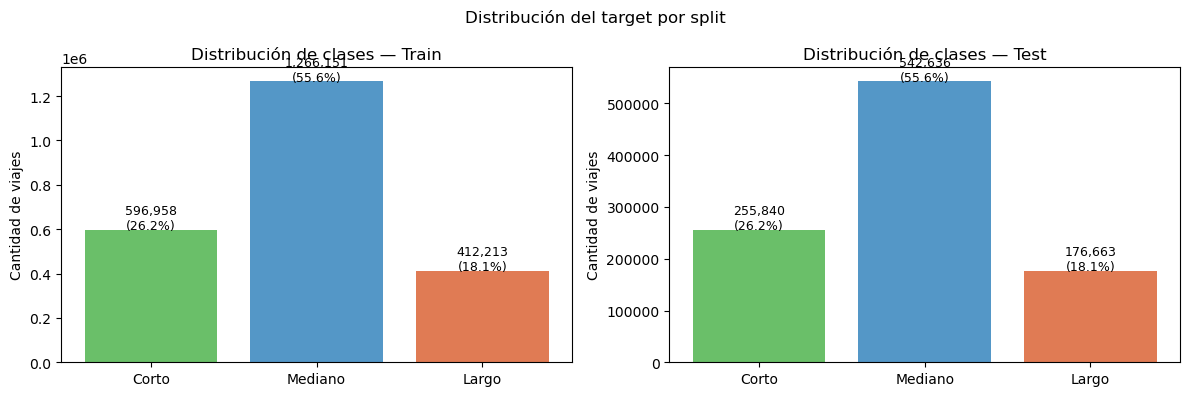

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#6abf69', '#5497c7', '#e07b54']

# Train
conteos_train = y_train.value_counts().reindex(etiquetas)
axes[0].bar(etiquetas, conteos_train, color=colores)
axes[0].set_title('Distribución de clases — Train')
axes[0].set_ylabel('Cantidad de viajes')
for i, (v, pct) in enumerate(zip(conteos_train, conteos_train / conteos_train.sum())):
    axes[0].text(i, v + 3000, f'{v:,}\n({pct:.1%})', ha='center', fontsize=9)

# Test
conteos_test = y_test.value_counts().reindex(etiquetas)
axes[1].bar(etiquetas, conteos_test, color=colores)
axes[1].set_title('Distribución de clases — Test')
axes[1].set_ylabel('Cantidad de viajes')
for i, (v, pct) in enumerate(zip(conteos_test, conteos_test / conteos_test.sum())):
    axes[1].text(i, v + 1000, f'{v:,}\n({pct:.1%})', ha='center', fontsize=9)

plt.suptitle('Distribución del target por split', fontsize=12)
plt.tight_layout()
plt.show()

### 7.1 Decisión sobre balance de clases

La consigna pide *"proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección"*. Analizamos la situación:

**Distribución observada en train** (`stratify=y` garantiza igual proporción en test):

| Clase | Proporción | Categoría |
|---|---|---|
| Mediano (10–30 min) | 55,6 % | Mayoritaria |
| Corto (< 10 min)    | 26,2 % | Intermedia |
| Largo (> 30 min)    | 18,1 % | Minoritaria |

**Decisión: NO se aplica rebalanceo artificial** (SMOTE / undersampling / oversampling). Razones:

1. **El desbalance es moderado, no severo.** Ninguna clase cae por debajo del 15 % ni domina por encima del 70 %. La ratio entre la clase más y menos frecuente es ≈ 3:1, lejos de los ratios 50:1 o 100:1 que justifican SMOTE.
2. **La distribución de clases refleja la realidad operativa.** `Mediano` es mayoritaria porque la mayoría de los viajes de EcoBici caen en el tramo gratuito de 10–30 min — es información útil, no ruido. Reequilibrar artificialmente distorsionaría el punto de operación del modelo.
3. **`stratify=y` ya resuelve el problema downstream más crítico**: que el modelo no vea una distribución distinta en train vs test. Las tres clases conservan su proporción en ambos subsets (celda 54).
4. **Los modelos candidatos soportan `class_weight='balanced'`** (Logistic Regression, SVM, Random Forest, XGBoost). Este mecanismo es más eficiente que SMOTE porque:
   - No genera datos sintéticos (no inventa viajes que no existieron).
   - Ajusta la función de pérdida proporcional a la inversa de la frecuencia de cada clase.
   - Se aplica al momento del entrenamiento, no en el pipeline de preparación.
5. **SMOTE sobre features mixtas (continuas + binarias) requiere variantes específicas** (SMOTENC, BorderlineSMOTE) que complican el pipeline sin ganancia clara dado (1), (2) y (4).

**Conclusión:** el dataset exportado conserva la distribución natural (`y_train.csv` / `y_test.csv`). El balanceo se delega al entrenador mediante `class_weight`, que es la estrategia técnicamente preferida para desbalance moderado.

---
## 8. Encoding de variables categóricas

### 8.1 `modelo_bicicleta` — Label Encoding

Solo tiene 2 valores: FIT (mecánica) e ICONIC (eléctrica). Con dos categorías,
Label Encoding alcanza y no introduce multicolinealidad.

In [31]:
le = LabelEncoder()
X_train['modelo_bicicleta'] = le.fit_transform(X_train['modelo_bicicleta'])
X_test['modelo_bicicleta']  = le.transform(X_test['modelo_bicicleta'])

print('Mapping modelo_bicicleta:', dict(zip(le.classes_, le.transform(le.classes_))))

Mapping modelo_bicicleta: {'FIT': np.int64(0), 'ICONIC': np.int64(1)}


### 8.2 `genero` — One-Hot Encoding

Tiene 3 categorías (FEMALE, MALE, OTHER). OHE con `drop_first=True` elimina una
columna para evitar multicolinealidad perfecta. MALE queda como categoría de referencia.

In [32]:
X_train = pd.get_dummies(X_train, columns=['genero'], drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['genero'], drop_first=True, dtype=int)

# Alinear columnas: asegura que test tiene exactamente las mismas que train
# (por si alguna categoría no aparece en test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Columnas de género generadas:', [c for c in X_train.columns if 'genero' in c])

Columnas de género generadas: ['genero_MALE', 'genero_OTHER']


### 8.3 `dia_semana` — One-Hot Encoding

Se mantiene el día completo (no solo `es_fin_de_semana`) para que el modelo
pueda capturar variaciones dentro de la semana laboral (ej: lunes vs viernes).
Se descarta una columna (`drop_first=True`) para evitar multicolinealidad.

In [33]:
X_train = pd.get_dummies(X_train, columns=['dia_semana'], drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['dia_semana'], drop_first=True, dtype=int)

# Alinear columnas nuevamente después de OHE de dia_semana
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Columnas de día generadas:', [c for c in X_train.columns if 'dia_semana' in c])
print('\nFeatures finales:', X_train.columns.tolist())
print('\nShape train:', X_train.shape)
print('Shape test: ', X_test.shape)

Columnas de día generadas: ['dia_semana_Monday', 'dia_semana_Saturday', 'dia_semana_Sunday', 'dia_semana_Thursday', 'dia_semana_Tuesday', 'dia_semana_Wednesday']

Features finales: ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'es_fin_de_semana', 'distancia_km', 'lat_estacion_origen', 'long_estacion_origen', 'lat_estacion_destino', 'long_estacion_destino', 'modelo_bicicleta', 'genero_MALE', 'genero_OTHER', 'dia_semana_Monday', 'dia_semana_Saturday', 'dia_semana_Sunday', 'dia_semana_Thursday', 'dia_semana_Tuesday', 'dia_semana_Wednesday']

Shape train: (2275322, 19)
Shape test:  (975139, 19)


---
## 9. Escalado con StandardScaler

Se aplica **StandardScaler** (media 0, desvío estándar 1) sobre las features numéricas continuas.
Esto es necesario para:
- Modelos lineales (Logistic Regression, SVM) que son sensibles a la escala.
- Modelos basados en distancia (KNN).
- Modelos con regularización (Ridge, Lasso, Elastic Net).

Árboles y bosques (Random Forest, XGBoost, LightGBM) no necesitan escalado, pero
mantenerlo no los perjudica y permite usar el mismo pipeline para todos los
modelos que se comparen.

El scaler se **ajusta solo con train** y se aplica a test, para evitar data leakage.

In [34]:
# Features que SÍ se escalan: todas las numéricas continuas
# Las coordenadas tienen rangos distintos entre sí (lat ~-34, long ~-58)
# y necesitan escalado para que el modelo las trate en igualdad de condiciones.
COLS_A_ESCALAR = [
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
    'distancia_km',
    'lat_estacion_origen', 'long_estacion_origen',
    'lat_estacion_destino', 'long_estacion_destino'
]
#nota1
scaler = StandardScaler()
X_train[COLS_A_ESCALAR] = scaler.fit_transform(X_train[COLS_A_ESCALAR])
X_test[COLS_A_ESCALAR]  = scaler.transform(X_test[COLS_A_ESCALAR])

print('Medias en train tras escalar (deben ser ≈ 0):')
print(X_train[COLS_A_ESCALAR].mean().round(6))
print('\nDesvíos en train (deben ser ≈ 1):')
print(X_train[COLS_A_ESCALAR].std().round(6))
print('\nMedias en test (no serán exactamente 0, es esperado):')
print(X_test[COLS_A_ESCALAR].mean().round(4))

Medias en train tras escalar (deben ser ≈ 0):
hora_sin                 0.0
hora_cos                -0.0
mes_sin                 -0.0
mes_cos                  0.0
distancia_km             0.0
lat_estacion_origen      0.0
long_estacion_origen     0.0
lat_estacion_destino     0.0
long_estacion_destino   -0.0
dtype: float64

Desvíos en train (deben ser ≈ 1):
hora_sin                 1.0
hora_cos                 1.0
mes_sin                  1.0
mes_cos                  1.0
distancia_km             1.0
lat_estacion_origen      1.0
long_estacion_origen     1.0
lat_estacion_destino     1.0
long_estacion_destino    1.0
dtype: float64

Medias en test (no serán exactamente 0, es esperado):
hora_sin                -0.0028
hora_cos                -0.0007
mes_sin                 -0.0020
mes_cos                  0.0008
distancia_km            -0.0003
lat_estacion_origen      0.0006
long_estacion_origen     0.0008
lat_estacion_destino     0.0004
long_estacion_destino    0.0015
dtype: float64


---
## 10. Verificación final del dataset

Revisión de integridad antes de exportar: sin nulos, tipos correctos, shapes consistentes.

In [35]:
print('=' * 50)
print('RESUMEN FINAL DEL DATASET')
print('=' * 50)
print(f'\nX_train: {X_train.shape} — nulos: {X_train.isna().sum().sum()}')
print(f'X_test:  {X_test.shape}  — nulos: {X_test.isna().sum().sum()}')
print(f'y_train: {y_train.shape} — clases: {y_train.value_counts().to_dict()}')
print(f'y_test:  {y_test.shape}  — clases: {y_test.value_counts().to_dict()}')

print('\nFeatures y sus tipos:')
print(X_train.dtypes)

print('\nEstadísticas X_train:')
X_train.describe().round(3)

RESUMEN FINAL DEL DATASET

X_train: (2275322, 19) — nulos: 0
X_test:  (975139, 19)  — nulos: 0
y_train: (2275322,) — clases: {'Mediano': 1266151, 'Corto': 596958, 'Largo': 412213}
y_test:  (975139,)  — clases: {'Mediano': 542636, 'Corto': 255840, 'Largo': 176663}

Features y sus tipos:
hora_sin                 float64
hora_cos                 float64
mes_sin                  float64
mes_cos                  float64
es_fin_de_semana           int64
distancia_km             float64
lat_estacion_origen      float64
long_estacion_origen     float64
lat_estacion_destino     float64
long_estacion_destino    float64
modelo_bicicleta           int64
genero_MALE                int64
genero_OTHER               int64
dia_semana_Monday          int64
dia_semana_Saturday        int64
dia_semana_Sunday          int64
dia_semana_Thursday        int64
dia_semana_Tuesday         int64
dia_semana_Wednesday       int64
dtype: object

Estadísticas X_train:


,hora_sin,hora_cos,mes_sin,mes_cos,es_fin_de_semana,distancia_km,lat_estacion_origen,long_estacion_origen,lat_estacion_destino,long_estacion_destino,modelo_bicicleta,genero_MALE,genero_OTHER,dia_semana_Monday,dia_semana_Saturday,dia_semana_Sunday,dia_semana_Thursday,dia_semana_Tuesday,dia_semana_Wednesday
count,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000,2275322.000
mean,0.000,-0.000,-0.000,0.000,0.131,0.000,0.000,0.000,0.000,-0.000,0.281,0.610,0.073,0.165,0.066,0.065,0.180,0.177,0.175
std,1.000,1.000,1.000,1.000,0.337,1.000,1.000,1.000,1.000,1.000,0.449,0.488,0.260,0.372,0.249,0.246,0.384,0.382,0.380
min,-0.987,-1.234,-1.362,-1.557,0.000,-1.327,-3.685,-2.719,-3.616,-2.700,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.936,-0.758,-1.175,-0.835,0.000,-0.656,-0.730,-0.698,-0.716,-0.690,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,-0.550,-0.028,0.033,-0.113,0.000,-0.219,-0.084,0.050,-0.077,0.055,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.891,0.814,0.731,1.137,0.000,0.455,0.669,0.812,0.666,0.762,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.996,2.021,1.428,1.331,1.000,8.413,2.567,1.759,2.532,1.755,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


---
## 11. Reducción de dimensionalidad

La Consigna 6 del TP pide dos cosas:

1. **Selección de features** con mecanismos vistos en clase (*ej: filtros*).
2. **Extracción de features** mediante técnicas de reducción de dimensionalidad (*ej: PCA*). Evaluar ventajas y desventajas.

Ambos bullets se resolvieron a lo largo del notebook. Esta sección consolida las decisiones y documenta los criterios técnicos aplicados a este dataset en particular.

### 11.1 Selección de features mediante filtros — **Mutual Information**

Aplicamos **Mutual Information** (MI) como método de filtro para rankear la importancia de las features numéricas frente al target categórico `tipo_viaje`. La implementación está en la sección 5 del notebook (`sklearn.feature_selection.mutual_info_classif`, calculada sobre una muestra de 200.000 filas para hacer el cómputo tratable).

**Por qué MI y no Pearson/ANOVA:**
- El target es categórico (3 clases) y las features son continuas → Pearson no aplica.
- MI captura relaciones **no lineales** entre cada feature y la clase, a diferencia de Pearson que solo mide asociación lineal.
- Es *modelo-agnóstica*: no presupone linealidad, ni gaussianidad, ni una función de decisión específica.

**Resultado del ranking** (ver gráfico en sección 5): las features geográficas (`distancia_km`, coordenadas) y la cíclica `hora_*` son las que más información aportan sobre la clase de viaje; el indicador `es_fin_de_semana` y las cíclicas de `mes` aportan menos.

**Decisión:** mantenemos **todas** las features del ranking en el dataset final. En esta etapa priorizamos no-descartar información; la selección fina por importancia queda para la etapa de modelado (fuera del alcance del TP).

### 11.2 Extracción de features — codificación cíclica + distancia Haversine

La **extracción de features** se implementó con dos técnicas de reducción **con justificación de dominio**, ambas aplicadas en la sección 3 de Feature Engineering:

| Técnica | Celda | Transformación | Reducción |
|---|---|---|---|
| Encoding cíclico sobre `hora` | 3.2 | `hora` (nominal 0–23) → `hora_sin`, `hora_cos` | 23 dummies (one-hot) → **2 continuas** |
| Encoding cíclico sobre `mes` | 3.2 | `mes` (nominal 1–12) → `mes_sin`, `mes_cos` | 11 dummies (one-hot) → **2 continuas** |
| Distancia Haversine | 3.4 | `lat_origen`, `long_origen`, `lat_destino`, `long_destino` → `distancia_km` | **4 features → 1** escalar interpretable |

**Por qué son técnicas de extracción genuinas:**

- **Encoding cíclico** no es solo una transformación: convierte una variable nominal con 24 valores (que necesitaría 23 columnas one-hot) en **dos dimensiones continuas** que preservan la topología circular del tiempo. Es una reducción **23 → 2** con recuperación casi perfecta de la información (la fase se recupera con `atan2(sin, cos)`). Lo mismo vale para `mes` (11 → 2).
- **Haversine** condensa las 4 coordenadas geográficas en **un único escalar interpretable** (kilómetros entre origen y destino) que captura la geometría esencial del viaje sobre la esfera terrestre. Es la feature que ocupa el top 1 del ranking de Mutual Information (ver sección 5), lo que confirma empíricamente su poder discriminativo.

Estas no son transformaciones cosméticas: son reducciones de dimensionalidad **informadas por dominio**, con la ventaja adicional de producir features interpretables.

### 11.3 Evaluación de ventajas y desventajas — decisión sobre PCA

La consigna menciona PCA como ejemplo (*ej: PCA*) y pide evaluar ventajas y desventajas de la reducción. Evaluamos aplicar PCA sobre este dataset y concluimos **no aplicarlo**, por cuatro razones técnicas concretas:

**1. Dimensionalidad final ya baja.** Tras encoding, el dataset de modelado tiene ~16 features (10 continuas + 6 binarias de dummies). PCA se justifica cuando hay decenas o cientos de features colineales; aquí la reducción adicional sería marginal.

**2. Las features continuas ya están ortogonalizadas por construcción.**
- `hora_sin` ⊥ `hora_cos` (identidad trigonométrica sin² + cos² = 1 con media 0).
- `mes_sin` ⊥ `mes_cos` (ídem).
- `distancia_km` es geométricamente independiente de las coordenadas absolutas.
- PCA sobre features ya ortogonales devuelve componentes que coinciden prácticamente con los ejes originales, sin aportar información nueva.

**3. Meter features binarias en PCA viola los supuestos del método.** PCA asume variables continuas con varianza comparable y distribución aproximadamente normal. Las 6 binarias (`es_fin_de_semana`, `genero_M`, 4 dummies de `dia_semana`, `modelo_bicicleta` label-encoded) rompen ese supuesto. La alternativa técnicamente correcta sería aplicar **FAMD** (Factor Analysis of Mixed Data), pero el costo pedagógico no se justifica para este alcance.

**4. Los modelos candidatos downstream son basados en árboles** (Random Forest, XGBoost, LightGBM — ver discusión del Integrante 5 en la defensa). Estos modelos son invariantes a rotaciones lineales de features y no se benefician de PCA. De hecho, se suele desaconsejar PCA previo a árboles porque destruye la interpretabilidad de la *feature importance*.

**Ventajas de las técnicas de extracción aplicadas** (cíclico + Haversine) **sobre PCA en este caso:**

- **Interpretabilidad preservada:** cada feature extraída tiene sentido físico directo (coordenada trigonométrica del tiempo, distancia real en kilómetros).
- **No suponen linealidad:** el encoding cíclico captura estructura circular, inherentemente no lineal.
- **No requieren homogeneidad de escala ni gaussianidad:** son válidas para features mixtas.
- **Justificación de dominio:** el TP tiene un objetivo aplicado (predecir la clase de viaje); las técnicas elegidas alinean la reducción con la naturaleza del problema (tiempo cíclico, geografía esférica).

**Desventajas** (honestidad intelectual):

- Son **específicas del dominio** — no generalizan automáticamente a otros datasets.
- No optimizan explícitamente una métrica de varianza preservada como PCA.
- No hay un único criterio objetivo para decidir cuántos features extraer (PCA lo da vía varianza acumulada).

**Conclusión y decisión de pipeline:** el dataset final exportado en la sección 12 (`X_train.csv` / `X_test.csv`) usa las features post-extracción cíclica + Haversine. **No se aplica PCA adicional.** Esta decisión está justificada por dominio y por las características del pipeline de modelado previsto.

---
## 12. Exportación

Se exportan los cuatro archivos CSV a la carpeta `../dataset/` (relativa a la ubicación del notebook).
Los índices se preservan para poder trazar cada fila de vuelta al dataset original si hace falta auditar.


In [36]:
# Exportación de los 4 archivos CSV a ../dataset/
X_train.to_csv(os.path.join(DATASET_DIR, 'X_train.csv'), index=True)
X_test.to_csv( os.path.join(DATASET_DIR, 'X_test.csv'),  index=True)
y_train.to_csv(os.path.join(DATASET_DIR, 'y_train.csv'), index=True, header=True)
y_test.to_csv( os.path.join(DATASET_DIR, 'y_test.csv'),  index=True, header=True)

print('Archivos exportados a', os.path.abspath(DATASET_DIR), ':')
print(f'  X_train.csv — {X_train.shape}')
print(f'  X_test.csv  — {X_test.shape}')
print(f'  y_train.csv — {y_train.shape}')
print(f'  y_test.csv  — {y_test.shape}')

Archivos exportados:
  X_train.csv — (2275322, 19)
  X_test.csv  — (975139, 19)
  y_train.csv — (2275322,) | clases: {'Mediano': 1266151, 'Corto': 596958, 'Largo': 412213}
  y_test.csv  — (975139,)  | clases: {'Mediano': 542636, 'Corto': 255840, 'Largo': 176663}

Para cargar en el notebook de modelado:
  X_train = pd.read_csv('X_train.csv', index_col=0)
  X_test  = pd.read_csv('X_test.csv',  index_col=0)
  y_train = pd.read_csv('y_train.csv', index_col=0).squeeze()
  y_test  = pd.read_csv('y_test.csv',  index_col=0).squeeze()
